# Pipeline A — hyper-parameter sweep with a run journal, plus the items requested in the correction report of 09/09/2026

Run order: §A → §B → §C → §D → §E → §F → §H → §I (→ §G optional). The U-Net is trained/loaded once; every refinement run appends one row to `results/pipelineA_runs.csv`; §F aggregates (mean ± std over seeds, “U-Net + CC cleanup” row, paired Wilcoxon test, HD95 in mm, cost per slice); §H computes the volumetric Dice on the 30 validation patients; §I produces the self-sufficient Figure 5.3.

Tags [B2], [B3], [B4], [P1.9], [P2.6] refer to the items of the correction report.

In [5]:
"""
PIPELINE A  --  U-Net -> phi0 -> Chan-Vese / coordinate-network refinement  (FLAIR + T1ce ONLY)

Modelling choice (justified in the thesis): the whole pipeline is restricted to FLAIR + T1ce.
  * FLAIR -> oedema and whole-tumour extent (WT).
  * T1ce  -> enhancing (active) tissue.
These two sequences cover the clinically decisive regions; restricting to them keeps the model
light and interpretable. It is a CHOICE, not a technical limitation. Honest consequence: the U-Net
WT Dice is slightly lower than with four modalities (WT is also visible on T2).

Already integrated (v2): float32 cast for figures, GEOMETRIC refiner (smooths without moving the
contour) + clean_mask, random evaluation sample.
"""

import os, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import nibabel as nib
    HAS_NIBABEL = True
except ImportError:
    HAS_NIBABEL = False
from scipy.ndimage import distance_transform_edt, binary_fill_holes, label as cc_label

PI = 3.141592653589793
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device : {device}")
torch.manual_seed(0); np.random.seed(0)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

DATA_DIR = ("/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

config = {
    # -- Data / U-Net: FLAIR + T1ce ONLY --
    "modalities": ["flair", "t1ce"],     # <<< project constraint (2 channels)
    "img_size": 128,
    "n_train_patients": 150, "n_val_patients": 30,
    "max_slices_per_patient": 40,
    "epochs": 70, "batch_size": 16, "lr": 1e-3,
    "weight_decay": 1e-4, "dropout": 0.10, "base_ch": 32,
    "augment": True, "use_tta": True,

    # -- Saving / reloading --
    "checkpoint": "/kaggle/working/unet_flair_t1ce.pt",
    "train_unet": False,       # False -> load the checkpoint (inference only)
    "cache_dir": "/kaggle/working/cache",         # preprocessed slices (.npz)
    "results_csv": "/kaggle/working/results/pipelineA_runs.csv",
    "fields_dir": "/kaggle/working/results/fields",

    # -- GEOMETRIC refinement (FLAIR+T1ce; smooths + cleans) --
    "fourier_dim": 64, "fourier_scale": 6.0, "hidden": [128, 128, 128],
    "phi_scale": 4.0, "delta_eps": 1.0,
    "warmup_steps": 400, "refine_steps": 200, "refine_lr": 2e-3,
    "mu": 0.03, "l_flair": 0.0, "l_t1ce": 0.0, "w_anchor": 15.0,
    "n_points": 6000, "c_update_every": 25,
    "refine_eval_slices": 20,
    "mm_per_px": 240.0 / 128,   # BraTS 1 mm iso, 240 -> 128 : 1.875 mm/px  [B2/P2.1]
}


# ═══════════════════════════════════════════════════════════
# §1  LOADING + AUGMENTATION + CLEANUP
# ═══════════════════════════════════════════════════════════

def _norm(img):
    b = img[img > 0]
    if len(b) == 0:
        return img.astype(np.float32)
    lo, hi = np.percentile(b, [1, 99])
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)


def load_volume(path, modalities):
    name = path.name

    def ff(s):
        for e in [".nii.gz", ".nii"]:
            f = path / f"{name}_{s}{e}"
            if f.exists():
                return str(f)
        raise FileNotFoundError(s)

    vols = [_norm(nib.load(ff(m)).get_fdata()) for m in modalities]
    sg = nib.load(ff("seg")).get_fdata().astype(np.int32)
    return vols, sg


def _resize(a, size, mode):
    t = torch.tensor(a, dtype=torch.float32)[None, None]
    if mode == "nearest":
        out = F.interpolate(t, size=(size, size), mode="nearest")
    else:
        out = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)
    return out[0, 0].numpy()


class BraTSSlices(torch.utils.data.Dataset):
    """2D slices: input = stacked modalities -> binary whole-tumour mask."""
    def __init__(self, patient_paths, modalities, size, max_slices):
        Xs, Ys, self.meta = [], [], []          # meta = (patient_id, z) per slice  [B2: IDs]
        for p in patient_paths:
            vols, sg = load_volume(p, modalities)
            zs = [z for z in range(sg.shape[2]) if (sg[:, :, z] > 0).sum() > 30]
            if len(zs) > max_slices:
                zs = [zs[i] for i in np.linspace(0, len(zs) - 1, max_slices).astype(int)]
            for z in zs:
                self.meta.append((p.name, int(z)))
                X = np.stack([_resize(v[:, :, z], size, "bilinear") for v in vols], 0)
                Y = (_resize((sg[:, :, z] > 0).astype(np.float32), size, "nearest") > 0.5)
                Xs.append(X.astype(np.float16)); Ys.append(Y.astype(np.float16)[None])
        self.X = torch.tensor(np.array(Xs)); self.Y = torch.tensor(np.array(Ys))
        print(f"  -> {len(self.X)} slices ({len(patient_paths)} patients), "
              f"{self.X.shape[1]} channels")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i].float(), self.Y[i].float()


def augment(X, Y):
    if torch.rand(1).item() < 0.5:
        X = torch.flip(X, [3]); Y = torch.flip(Y, [3])
    if torch.rand(1).item() < 0.5:
        X = torch.flip(X, [2]); Y = torch.flip(Y, [2])
    k = int(torch.randint(0, 4, (1,)).item())
    if k:
        X = torch.rot90(X, k, [2, 3]); Y = torch.rot90(Y, k, [2, 3])
    s = 1.0 + (torch.rand(X.shape[0], 1, 1, 1, device=X.device) - 0.5) * 0.2
    b = (torch.rand(X.shape[0], 1, 1, 1, device=X.device) - 0.5) * 0.1
    return torch.clamp(X * s + b, 0, 1), Y


def clean_mask(mask):
    """Fill holes and remove small islands (< 10% of the largest connected component)."""
    mask = binary_fill_holes(mask)
    lab, n = cc_label(mask)
    if n <= 1:
        return mask
    sizes = np.array([(lab == i).sum() for i in range(1, n + 1)])
    keep = np.zeros_like(mask)
    for i in range(1, n + 1):
        if sizes[i - 1] >= 0.10 * sizes.max():
            keep |= (lab == i)
    return keep


# ═══════════════════════════════════════════════════════════
# §2  U-NET 2D + TTA
# ═══════════════════════════════════════════════════════════

class DoubleConv(nn.Module):
    def __init__(self, ci, co, p=0.0):
        super().__init__()
        layers = [nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                  nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True)]
        if p > 0:
            layers.append(nn.Dropout2d(p))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch=2, base=32, p=0.1):
        super().__init__()
        self.d1 = DoubleConv(in_ch, base);        self.d2 = DoubleConv(base, base * 2)
        self.d3 = DoubleConv(base * 2, base * 4);  self.d4 = DoubleConv(base * 4, base * 8, p)
        self.pool = nn.MaxPool2d(2)
        self.bott = DoubleConv(base * 8, base * 16, p)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2); self.u4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2);  self.u3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2);  self.u2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2);      self.u1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2)); c4 = self.d4(self.pool(c3))
        b = self.bott(self.pool(c4))
        x = self.u4(torch.cat([self.up4(b), c4], 1))
        x = self.u3(torch.cat([self.up3(x), c3], 1))
        x = self.u2(torch.cat([self.up2(x), c2], 1))
        x = self.u1(torch.cat([self.up1(x), c1], 1))
        return self.out(x)


@torch.no_grad()
def predict_tta(model, X):
    ps = [torch.sigmoid(model(X)),
          torch.flip(torch.sigmoid(model(torch.flip(X, [3]))), [3]),
          torch.flip(torch.sigmoid(model(torch.flip(X, [2]))), [2])]
    return torch.stack(ps).mean(0)


# ═══════════════════════════════════════════════════════════
# §3  LOSSES, METRIC, TRAINING
# ═══════════════════════════════════════════════════════════

_bce = nn.BCEWithLogitsLoss()


def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2 * (p * target).sum((1, 2, 3)) + eps
    den = p.sum((1, 2, 3)) + target.sum((1, 2, 3)) + eps
    return (1 - num / den).mean()


@torch.no_grad()
def dice_metric(logits, target, thr=0.5):
    p = (torch.sigmoid(logits) > thr).float()
    num = 2 * (p * target).sum((1, 2, 3))
    den = p.sum((1, 2, 3)) + target.sum((1, 2, 3))
    d = torch.where(den < 1e-6, torch.ones_like(den), num / den)
    return d.mean().item()


def train_unet(model, train_dl, val_dl, cfg):
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg["epochs"])
    best, best_state, patience, since = 0.0, None, 15, 0
    print("\n[U-Net] Training (FLAIR + T1ce)...")
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        for X, Y in train_dl:
            X, Y = X.to(device), Y.to(device)
            if cfg["augment"]:
                X, Y = augment(X, Y)
            logit = model(X)
            loss = dice_loss(logit, Y) + _bce(logit, Y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()

        model.eval(); ds = []
        with torch.no_grad():
            for X, Y in val_dl:
                X, Y = X.to(device), Y.to(device)
                ds.append(dice_metric(model(X), Y))
        vd = float(np.mean(ds))
        if vd > best:
            best, since = vd, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            since += 1
        if ep % 2 == 0 or ep == 1:
            print(f"  Epoch {ep:2d}/{cfg['epochs']}  Dice(val WT)={vd:.4f}  (best={best:.4f})")
        if since >= patience:
            print(f"  [early stop] no improvement for {patience} epochs.")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"[U-Net] Best mean WT Dice (val) = {best:.4f}")
    return model, best


# ═══════════════════════════════════════════════════════════
# §4  GEOMETRIC REFINEMENT (length + anchor on phi0)
# ═══════════════════════════════════════════════════════════

class CVPINN(nn.Module):
    def __init__(self, fd=64, fs=6.0, hidden=(128, 128, 128), ps=4.0):
        super().__init__()
        self.phi_scale = ps
        self.register_buffer("B", torch.randn(2, fd) * fs)
        d = 2 * fd; layers = []
        for h in hidden:
            layers += [nn.Linear(d, h), nn.Tanh()]; d = h
        layers += [nn.Linear(d, 1)]
        self.mlp = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x, y):
        p = 2 * PI * torch.cat([x, y], -1) @ self.B
        return self.phi_scale * torch.tanh(self.mlp(torch.cat([torch.sin(p), torch.cos(p)], -1)))


def _g(u, v):
    return torch.autograd.grad(u, v, torch.ones_like(u), create_graph=True)[0]


def prob_to_phi0(prob, scale):
    mask = binary_fill_holes(prob > 0.5)
    if mask.sum() < 5:
        mask = prob > 0.5
    din = distance_transform_edt(mask); dout = distance_transform_edt(~mask)
    phi0 = (din - dout).astype(np.float32)
    return phi0 / (np.abs(phi0).max() + 1e-8) * scale


@torch.no_grad()
def _consts(model, X, Y, IFL, IT1, eps):
    phi = model(X, Y)
    Hin = 0.5 * (1 + (2 / PI) * torch.atan(phi / eps)); Hout = 1 - Hin
    wm = lambda I, w: (I * w).sum() / (w.sum() + 1e-8)
    return wm(IFL, Hin), wm(IFL, Hout), wm(IT1, Hin), wm(IT1, Hout)


def refine(flair, t1ce, prob, brain_mask, cfg, seed=None):
    if seed is not None:                     # one seed per (run, slice) -> reproducible refinement
        torch.manual_seed(seed)
    H, W = flair.shape
    phi0 = prob_to_phi0(prob, cfg["phi_scale"])
    rr, cc = np.where(brain_mask)
    Xn = torch.tensor(cc / (W - 1), dtype=torch.float32, device=device).view(-1, 1)
    Yn = torch.tensor(rr / (H - 1), dtype=torch.float32, device=device).view(-1, 1)
    IFL = torch.tensor(flair[rr, cc], dtype=torch.float32, device=device).view(-1, 1)
    IT1 = torch.tensor(t1ce[rr, cc], dtype=torch.float32, device=device).view(-1, 1)
    P0 = torch.tensor(phi0[rr, cc], dtype=torch.float32, device=device).view(-1, 1)
    N = Xn.shape[0]

    model = CVPINN(cfg["fourier_dim"], cfg["fourier_scale"], cfg["hidden"], cfg["phi_scale"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["refine_lr"])
    for _ in range(cfg["warmup_steps"]):
        idx = torch.randint(0, N, (cfg["n_points"],), device=device)
        loss = ((model(Xn[idx], Yn[idx]) - P0[idx]) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()

    eps = cfg["delta_eps"]
    use_data = (cfg["l_flair"] > 0) or (cfg["l_t1ce"] > 0)
    consts = _consts(model, Xn, Yn, IFL, IT1, eps) if use_data else (0, 0, 0, 0)
    for ep in range(1, cfg["refine_steps"] + 1):
        if use_data and ep % cfg["c_update_every"] == 0:
            consts = _consts(model, Xn, Yn, IFL, IT1, eps)
        idx = torch.randint(0, N, (cfg["n_points"],), device=device)
        x = Xn[idx].detach().requires_grad_(True); y = Yn[idx].detach().requires_grad_(True)
        phi = model(x, y); px = _g(phi, x); py = _g(phi, y)
        delta = (1.0 / PI) * eps / (eps ** 2 + phi ** 2)
        length = (delta * torch.sqrt(px ** 2 + py ** 2 + 1e-12)).mean()
        fid = 0.0
        if use_data:
            Hin = 0.5 * (1 + (2 / PI) * torch.atan(phi / eps)); Hout = 1 - Hin
            c1FL, c2FL, c1T1, c2T1 = consts
            fid = (cfg["l_flair"] * ((IFL[idx] - c1FL) ** 2 * Hin).mean()
                   + cfg["l_flair"] * ((IFL[idx] - c2FL) ** 2 * Hout).mean()
                   + cfg["l_t1ce"] * ((IT1[idx] - c1T1) ** 2 * Hin).mean()
                   + cfg["l_t1ce"] * ((IT1[idx] - c2T1) ** 2 * Hout).mean())
        anchor = ((phi - P0[idx]) ** 2).mean()
        E = cfg["mu"] * length + fid + cfg["w_anchor"] * anchor
        opt.zero_grad(); E.backward(); opt.step()

    with torch.no_grad():
        gx = torch.linspace(0, 1, W, device=device).repeat(H).view(-1, 1)
        gy = torch.repeat_interleave(torch.linspace(0, 1, H, device=device), W).view(-1, 1)
        phi = model(gx, gy).cpu().numpy().reshape(H, W)
    phi[~brain_mask] = phi[brain_mask].min()
    return phi


def dice_bin(p, g):
    i = (p & g).sum(); d = p.sum() + g.sum()
    return 1.0 if d < 1e-8 else 2.0 * i / d



[INFO] Device : cuda


In [6]:
# ═══════════════════════════════════════════════════════════
# §B  DATA (disk cache) + U-NET (trained ONCE)
# ═══════════════════════════════════════════════════════════
import json, time, hashlib
import pandas as pd

os.makedirs(config["cache_dir"], exist_ok=True)
os.makedirs(os.path.dirname(config["results_csv"]), exist_ok=True)
os.makedirs(config["fields_dir"], exist_ok=True)

sz, mods = config["img_size"], config["modalities"]
i_fl, i_t1 = mods.index("flair"), mods.index("t1ce")
pats = sorted([d for d in Path(DATA_DIR).iterdir() if d.is_dir()])
ntr, nva = config["n_train_patients"], config["n_val_patients"]
train_p, val_p = pats[:ntr], pats[ntr:ntr + nva]

def cached_slices(paths, tag):
    """BraTSSlices is built once, then reloaded from .npz (saves several minutes per run)."""
    f = Path(config["cache_dir"]) / f"{tag}_{len(paths)}p_{sz}px_{config['max_slices_per_patient']}s_v2.npz"
    if f.exists():
        z = np.load(f,allow_pickle = True)
        ds = BraTSSlices.__new__(BraTSSlices)
        ds.X, ds.Y = torch.tensor(z["X"]), torch.tensor(z["Y"])
        ds.meta = [(str(a), int(b)) for a, b in z["meta"]]
        print(f"[cache] {tag}: {len(ds.X)} slices reloaded from {f.name}")
        return ds
    ds = BraTSSlices(paths, mods, sz, config["max_slices_per_patient"])
    np.savez_compressed(f, X=ds.X.numpy(), Y=ds.Y.numpy(), meta=np.array(ds.meta, dtype=object))
    return ds

val_ds = cached_slices(val_p, "val")
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=config["batch_size"])
unet = UNet(len(mods), config["base_ch"], config["dropout"]).to(device)

if config["train_unet"] or not os.path.exists(config["checkpoint"]):
    print("[U-Net] training (once only; afterwards set train_unet=False)")
    train_ds = cached_slices(train_p, "train")
    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    unet, best_val = train_unet(unet, train_dl, val_dl, config)
    torch.save(unet.state_dict(), config["checkpoint"])
else:
    unet.load_state_dict(torch.load(config["checkpoint"], map_location=device))
    unet.eval()
    with torch.no_grad():
        best_val = float(np.mean([dice_metric(unet(X.to(device)), Y.to(device)) for X, Y in val_dl]))
    print(f"[U-Net] checkpoint reloaded -- val WT Dice (all slices) = {best_val:.4f}")
unet.eval()

# evaluation slices: identical to main() and to the measurement cell (rng 0)
rng = np.random.default_rng(0)
cand = [i for i in range(len(val_ds)) if float(val_ds.Y[i].sum()) > 50]
K = min(config["refine_eval_slices"], len(cand))
sel = [int(k) for k in rng.choice(cand, size=K, replace=False)]

# [B2] one file with everything the jury needs to reproduce the protocol
protocol = {
    "train_patients": [p.name for p in train_p], "val_patients": [p.name for p in val_p],
    "eval_slices": [{"idx": k, "patient": val_ds.meta[k][0], "z": val_ds.meta[k][1],
                     "wt_pixels": int(val_ds.Y[k].sum())} for k in sel],
    "eval_slice_rule": "val slices with >50 WT pixels at 128x128, 20 drawn with np.random.default_rng(0), no replacement",
    "cc_cleanup_rule": "fill holes, then keep every connected component >= 10% of the largest one",
    "dice_empty_rule": "Dice := 1 when prediction and GT are both empty; HD95 := NaN (excluded from means) when either mask is empty",
    "resize": "F.interpolate 240->128, bilinear for images, nearest for labels; percentile [1,99] normalisation per volume on non-zero voxels, before the brain mask I_FL>0.02",
    "versions": {"torch": torch.__version__, "cuda": torch.version.cuda, "numpy": np.__version__,
                 "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"},
    "config": {k: (v if not isinstance(v, list) else str(v)) for k, v in config.items()},
}
try:
    import sklearn, nibabel, scipy; protocol["versions"].update(sklearn=sklearn.__version__, nibabel=nibabel.__version__, scipy=scipy.__version__)
except Exception: pass
json.dump(protocol, open("/kaggle/working/results/protocol_pipelineA.json", "w"), indent=1)
print("[B2] protocol + IDs -> results/protocol_pipelineA.json")
print("[B2] eval slices (patient, z):", [(val_ds.meta[k][0][-3:], val_ds.meta[k][1]) for k in sel])

def _slice_data(k):
    X = val_ds.X[k:k + 1].float().to(device)
    gt = val_ds.Y[k, 0].numpy().astype(np.float32).astype(bool)
    prob = (predict_tta(unet, X) if config["use_tta"]
            else torch.sigmoid(unet(X)))[0, 0].detach().cpu().numpy().astype(np.float32)
    flair = val_ds.X[k, i_fl].numpy().astype(np.float32)
    t1ce = val_ds.X[k, i_t1].numpy().astype(np.float32)
    return flair, t1ce, gt, prob, flair > 0.02

# U-Net predictions do not depend on the refinement config -> computed once
SLICES = {k: _slice_data(k) for k in sel}
print(f"[eval] {K} evaluation slices ready; U-Net Dice({K}) = "
      f"{np.mean([dice_bin(SLICES[k][3] > 0.5, SLICES[k][2]) for k in sel]):.4f}")


[cache] val: 1188 slices reloaded from val_30p_128px_40s_v2.npz
[U-Net] checkpoint reloaded -- val WT Dice (all slices) = 0.7729
[B2] protocol + IDs -> results/protocol_pipelineA.json
[B2] eval slices (patient, z): [('178', 69), ('160', 62), ('158', 62), ('179', 48), ('166', 39), ('168', 115), ('167', 74), ('180', 35), ('169', 58), ('170', 38), ('156', 37), ('174', 124), ('169', 63), ('151', 90), ('167', 48), ('153', 46), ('175', 99), ('165', 113), ('172', 102), ('152', 68)]
[eval] 20 evaluation slices ready; U-Net Dice(20) = 0.8326


In [7]:
# ═══════════════════════════════════════════════════════════
# §C  METRICS (identical to the original measurement cell)
# ═══════════════════════════════════════════════════════════


# ---------------------------------------------------------------------
#  1. Metrics
# ---------------------------------------------------------------------
def _delta_eps(phi, eps):
    return (1.0 / np.pi) * eps / (eps ** 2 + phi ** 2)


def contour_length(phi, eps=1.0, h=1.0):
    """Length(phi) -- Eq. (5.3)."""
    gy, gx = np.gradient(phi.astype(np.float64), h)
    return float((h ** 2) * np.sum(_delta_eps(phi, eps) * np.sqrt(gx ** 2 + gy ** 2)))


def mean_abs_curvature(phi, eps=1.0, h=1.0):
    """|kappa|(phi) -- Eq. (5.4), closed formula (3.23).

    NOTE: this is a property of the CONTOUR only when the field is well
    conditioned, i.e. |grad phi| is roughly constant near the zero level
    set. The denominator below carries |grad phi|^3, so a field that
    flattens near its zero crossing inflates the measured curvature.
    Compare with sdf_abs_curvature() and eikonal_deviation() below.
    """
    phi = phi.astype(np.float64)
    gy, gx = np.gradient(phi, h)
    gxy, gxx = np.gradient(gx, h)
    gyy, gyx = np.gradient(gy, h)
    num = gxx * gy ** 2 - 2.0 * gxy * gx * gy + gyy * gx ** 2
    den = (gx ** 2 + gy ** 2) ** 1.5 + 1e-8
    w = _delta_eps(phi, eps)
    return float(np.sum(w * np.abs(num / den)) / (np.sum(w) + 1e-12))


def to_signed_distance(phi, scale=None):
    """Rebuild a signed-distance function carrying the SAME zero level set.

    This removes the parameterisation of the field and keeps only its
    geometry, so that the curvature measured afterwards is a property of
    the contour alone.
    """
    m = phi > 0
    if m.sum() < 5 or (~m).sum() < 5:
        return None
    m = binary_fill_holes(m)
    sd = (distance_transform_edt(m) - distance_transform_edt(~m)).astype(np.float64)
    if scale is not None:
        sd = sd / (np.abs(sd).max() + 1e-8) * scale
    return sd


def sdf_abs_curvature(phi, eps=1.0, h=1.0, scale=4.0):
    """|kappa| measured after reprojection onto a signed-distance function.

    CAVEAT, to state in the thesis: the reprojection goes through the
    binary mask (phi > 0), so the rebuilt contour is rasterised on the
    pixel grid and its discrete curvature is biased UPWARDS. On an exact
    disc of radius 40 this returns about 0.131 where the true curvature is
    0.025. The absolute value is therefore not a curvature estimate.

    What it IS good for: the bias depends only on the contour, not on the
    field carrying it. Feeding it an exact signed-distance function and a
    tanh-squashed field with the SAME zero level set returns the same
    0.131 in both cases, whereas the raw curvature differs. The
    before/after COMPARISON is thus meaningful even though the level is
    not, which is exactly what Table 5.3 needs.
    """
    sd = to_signed_distance(phi, scale)
    return np.nan if sd is None else mean_abs_curvature(sd, eps, h)


def eikonal_deviation(phi, eps=1.0, h=1.0):
    """Scale-free deviation from |grad phi| = const near the zero level set.

    Returns std(|grad phi|)/mean(|grad phi|), weighted by delta_eps. It is
    0 for an exact signed-distance function and grows as the field loses
    that property. Being a ratio, it is invariant under phi -> c*phi, so
    phi_0 and phi_theta can be compared even though their scalings differ.
    """
    gy, gx = np.gradient(phi.astype(np.float64), h)
    g = np.sqrt(gx ** 2 + gy ** 2)
    w = _delta_eps(phi, eps)
    mu = np.sum(w * g) / (np.sum(w) + 1e-12)
    var = np.sum(w * (g - mu) ** 2) / (np.sum(w) + 1e-12)
    return float(np.sqrt(var) / (mu + 1e-12))


def hd95(pred, gt):
    """Symmetric 95th-percentile Hausdorff distance -- Eq. (5.2), in pixels.
    Returns nan when either mask is empty (undefined, not zero)."""
    pred = np.asarray(pred, bool)
    gt = np.asarray(gt, bool)
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan

    def _bnd(m):
        er = np.zeros_like(m)
        er[1:-1, 1:-1] = (m[1:-1, 1:-1] & m[:-2, 1:-1] & m[2:, 1:-1]
                          & m[1:-1, :-2] & m[1:-1, 2:])
        return m & ~er

    bp, bg = _bnd(pred), _bnd(gt)
    if bp.sum() == 0 or bg.sum() == 0:
        return np.nan
    d_gt = distance_transform_edt(~bg)
    d_pr = distance_transform_edt(~bp)
    return float(max(np.percentile(d_gt[bp], 95), np.percentile(d_pr[bg], 95)))




In [8]:
# ═══════════════════════════════════════════════════════════
# §D  ONE RUN = one refinement config + one seed -> one row in the CSV journal
# ═══════════════════════════════════════════════════════════
SWEEP_KEYS = ["mu", "w_anchor", "l_flair", "l_t1ce", "warmup_steps", "refine_steps",
              "refine_lr", "fourier_dim", "fourier_scale", "hidden", "phi_scale",
              "delta_eps", "n_points"]          # what identifies a configuration

def cfg_id(cfg):
    s = json.dumps({k: cfg[k] for k in SWEEP_KEYS}, sort_keys=True)
    return hashlib.md5(s.encode()).hexdigest()[:8]

def load_journal():
    p = config["results_csv"]
    return pd.read_csv(p) if os.path.exists(p) else pd.DataFrame()

def run_experiment(cfg, seed, tag="", save_fields=False):
    """Refine the K slices with `cfg`, compute every metric of Tables 5.1/5.3,
    append one row to the CSV and return it. Skips runs already in the journal."""
    cid = cfg_id(cfg)
    J = load_journal()
    if len(J) and ((J.cfg_id == cid) & (J.seed == seed)).any():
        print(f"[skip] {cid} seed={seed} already in the journal")
        return J[(J.cfg_id == cid) & (J.seed == seed)].iloc[0]

    eps, ps = cfg["delta_eps"], cfg["phi_scale"]
    acc = {k: [] for k in ["du", "dcc", "dr", "h0", "hcc", "h1", "L0", "L1", "k0", "k1", "s0", "s1", "e0", "e1", "sec"]}
    fields, t0 = [], time.time()
    for j, k in enumerate(sel):
        flair, t1ce, gt, prob, brain = SLICES[k]
        um = prob > 0.5
        ucc = clean_mask(um & brain)                              # [B4] U-Net + CC cleanup, no refinement
        phi0 = prob_to_phi0(prob, ps)
        t1 = time.time()
        phi = refine(flair, t1ce, prob, brain, cfg, seed=seed * 1000 + j)
        acc["sec"].append(time.time() - t1)                       # [B2] cost per slice
        rm = clean_mask((phi > 0) & brain)
        acc["du"].append(dice_bin(um, gt)); acc["dcc"].append(dice_bin(ucc, gt)); acc["dr"].append(dice_bin(rm, gt))
        acc["h0"].append(hd95(um, gt));     acc["hcc"].append(hd95(ucc, gt));     acc["h1"].append(hd95(rm, gt))
        acc["L0"].append(contour_length(phi0, eps));  acc["L1"].append(contour_length(phi, eps))
        acc["k0"].append(mean_abs_curvature(phi0, eps)); acc["k1"].append(mean_abs_curvature(phi, eps))
        acc["s0"].append(sdf_abs_curvature(phi0, eps, scale=ps)); acc["s1"].append(sdf_abs_curvature(phi, eps, scale=ps))
        acc["e0"].append(eikonal_deviation(phi0, eps)); acc["e1"].append(eikonal_deviation(phi, eps))
        if save_fields:
            fields.append({"k": k, "phi0": phi0.copy(), "phi": phi.copy(), "brain": brain.copy()})

    m = {k: float(np.nanmean(v)) for k, v in acc.items()}
    row = {"cfg_id": cid, "seed": seed, "tag": tag, "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
           "K": K, "unet_val_all": best_val, "seconds": round(time.time() - t0, 1),
           **{k: cfg[k] if not isinstance(cfg[k], list) else str(cfg[k]) for k in SWEEP_KEYS},
           **{f"m_{k}": v for k, v in m.items()},
           "dDice": m["dr"] - m["du"], "dHD95": m["h1"] - m["h0"],
           "dHD95_cc_only": m["hcc"] - m["h0"], "dHD95_refine_vs_cc": m["h1"] - m["hcc"],
           "m_h0_mm": m["h0"] * cfg["mm_per_px"], "m_hcc_mm": m["hcc"] * cfg["mm_per_px"], "m_h1_mm": m["h1"] * cfg["mm_per_px"],
           "sec_per_slice": m["sec"],
           "pct_len": 100 * (m["L1"] - m["L0"]) / (abs(m["L0"]) + 1e-12),
           "pct_kSDF": 100 * (m["s1"] - m["s0"]) / (abs(m["s0"]) + 1e-12),
           "best_slice_dr": max(acc["dr"]),
           "per_slice_du": json.dumps([round(x, 4) for x in acc["du"]]),
           "per_slice_dcc": json.dumps([round(x, 4) for x in acc["dcc"]]),
           "per_slice_dr": json.dumps([round(x, 4) for x in acc["dr"]]),
           "per_slice_h0": json.dumps([None if np.isnan(x) else round(x, 2) for x in acc["h0"]]),
           "per_slice_h1": json.dumps([None if np.isnan(x) else round(x, 2) for x in acc["h1"]])}
    pd.DataFrame([row]).to_csv(config["results_csv"], mode="a", index=False,
                               header=not os.path.exists(config["results_csv"]))
    if save_fields:
        np.savez_compressed(f"{config['fields_dir']}/{cid}_s{seed}.npz",
                            **{f"{f['k']}_{n}": f[n] for f in fields for n in ("phi0", "phi", "brain")})
    print(f"[run ] {cid} seed={seed} {tag:<14} Dice {m['du']:.4f}->{m['dr']:.4f} ({m['dr']-m['du']:+.4f}) "
          f"HD95 {m['h0']:.2f}->{m['hcc']:.2f}(cc)->{m['h1']:.2f}px len {row['pct_len']:+.1f}% {m['sec']:.1f}s/slice "
          f"[{row['seconds']}s]")
    return pd.Series(row)


In [9]:
# ═══════════════════════════════════════════════════════════
# §E  EXPERIMENT GRID -- edit freely and re-run: runs already done are skipped
# ═══════════════════════════════════════════════════════════
SEEDS = [0, 1, 2]                         # 3 seeds per config -> mean ± std

grid = [
    ("reported",     {}),                                  # configuration reported in the thesis
    ("mu_0.01",      {"mu": 0.01}),
    ("mu_0.05",      {"mu": 0.05}),
    ("mu_0.10",      {"mu": 0.10}),
    ("wa_5",         {"w_anchor": 5.0}),
    ("wa_30",        {"w_anchor": 30.0}),
    ("steps_500",    {"refine_steps": 500}),
    ("eps_0.5",      {"delta_eps": 0.5}),
    ("ablat_length", {"w_anchor": 0.0}),                   # Table 5.2
    ("ablat_anchor", {"mu": 0.0}),                         # Table 5.2
]

for tag, over in grid:
    cfg = {**config, **over}
    for s in SEEDS:
        run_experiment(cfg, s, tag=tag, save_fields=(tag == "reported"))


[skip] ac9d84e0 seed=0 already in the journal
[skip] ac9d84e0 seed=1 already in the journal
[skip] ac9d84e0 seed=2 already in the journal
[skip] e1db84c4 seed=0 already in the journal
[skip] e1db84c4 seed=1 already in the journal
[skip] e1db84c4 seed=2 already in the journal
[skip] f4fea996 seed=0 already in the journal
[skip] f4fea996 seed=1 already in the journal
[skip] f4fea996 seed=2 already in the journal
[skip] 1a6cdcc3 seed=0 already in the journal
[skip] 1a6cdcc3 seed=1 already in the journal
[skip] 1a6cdcc3 seed=2 already in the journal
[skip] e7980211 seed=0 already in the journal
[skip] e7980211 seed=1 already in the journal
[skip] e7980211 seed=2 already in the journal
[skip] 210790bf seed=0 already in the journal
[skip] 210790bf seed=1 already in the journal
[skip] 210790bf seed=2 already in the journal
[skip] 1e523e3b seed=0 already in the journal
[skip] 1e523e3b seed=1 already in the journal
[skip] 1e523e3b seed=2 already in the journal
[skip] 959adffc seed=0 already in 

In [10]:
# ═══════════════════════════════════════════════════════════
# §F  SUMMARY: mean ± std per configuration, best-config selection, LaTeX rows
# ═══════════════════════════════════════════════════════════
J = load_journal()
agg = (J.groupby(["cfg_id", "tag"])
         .agg(n=("seed", "count"),
              Dice_unet=("m_du", "mean"),
              Dice_ref=("m_dr", "mean"), Dice_ref_sd=("m_dr", "std"),
              dDice=("dDice", "mean"), dDice_sd=("dDice", "std"),
              Dice_cc=("m_dcc", "mean"), HD95_cc=("m_hcc", "mean"),
              HD95_unet=("m_h0", "mean"), sec_slice=("sec_per_slice", "mean"),
              HD95_ref=("m_h1", "mean"), HD95_ref_sd=("m_h1", "std"),
              dHD95=("dHD95", "mean"), dHD95_sd=("dHD95", "std"),
              pct_len=("pct_len", "mean"), pct_kSDF=("pct_kSDF", "mean"),
              Eik_after=("m_e1", "mean"), mu=("mu", "first"), w_anchor=("w_anchor", "first"))
         .reset_index())

# Selection criterion (adapt as needed): largest HD95 improvement
# among the configs that do not lower the Dice by more than 0.005.
ok = agg[(agg.dDice >= -0.005) & (agg.w_anchor > 0)]
agg["selected"] = agg.cfg_id.isin(ok.sort_values("dHD95").head(1).cfg_id)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
print(agg.sort_values("dHD95").round(4).to_string(index=False))

best = agg[agg.selected].iloc[0]
print(f"\n>>> selected configuration: {best.tag} (id {best.cfg_id}, n={best.n} seeds)")
print(f"    Dice {best.Dice_unet:.4f} -> {best.Dice_ref:.4f} ± {best.Dice_ref_sd:.4f}   "
      f"HD95 {best.HD95_unet:.2f} -> {best.HD95_ref:.2f} ± {best.HD95_ref_sd:.2f}   "
      f"length {best.pct_len:+.1f}%   |kappa|SDF {best.pct_kSDF:+.1f}%")

# [P1.9] paired Wilcoxon test, per seed, on the 20 slices: refinement vs U-Net+CC (same cleanup on both sides)
from scipy.stats import wilcoxon
rows = J[J.cfg_id == best.cfg_id]
pv = []
for _, r in rows.iterrows():
    a, b = np.array(json.loads(r.per_slice_dcc)), np.array(json.loads(r.per_slice_dr))
    pv.append(wilcoxon(b, a).pvalue if np.any(b != a) else 1.0)
print(f"    Wilcoxon (Dice refined vs U-Net+CC, {int(rows.K.iloc[0])} paired slices), p per seed = {np.round(pv, 3)}")

mm = config["mm_per_px"]; n = int(J.K.iloc[0])
print(f"\n  Table 5.1 (n = {n} slices, refinement: mean ± std over {int(best.n)} seeds; HD95 in px and mm, 1 px = {mm:.3f} mm)")
print(f"    U-Net & ${best.Dice_unet:.4f}$ & ${best.HD95_unet:.2f}$ px (${best.HD95_unet*mm:.1f}$ mm) \\\\")
print(f"    U-Net $+$ CC cleanup (no refinement) & ${best.Dice_cc:.4f}$ & ${best.HD95_cc:.2f}$ px (${best.HD95_cc*mm:.1f}$ mm) \\\\")
print(f"    U-Net $+$ refinement $+$ CC cleanup & ${best.Dice_ref:.4f} \\pm {best.Dice_ref_sd:.4f}$ "
      f"& ${best.HD95_ref:.2f} \\pm {best.HD95_ref_sd:.2f}$ px (${best.HD95_ref*mm:.1f}$ mm) \\\\")
print(f"    $\\Delta$ cleanup alone & ${best.Dice_cc-best.Dice_unet:+.4f}$ & ${best.HD95_cc-best.HD95_unet:+.2f}$ \\\\")
print(f"    $\\Delta$ refinement on top of cleanup & ${best.Dice_ref-best.Dice_cc:+.4f}$ & ${best.HD95_ref-best.HD95_cc:+.2f}$ \\\\")
print(f"    cost: {best.sec_slice:.1f} s per slice (warm-up + refinement, {protocol['versions']['gpu']})")

agg.to_csv("/kaggle/working/results/pipelineA_summary.csv", index=False)
print("\n[INFO] journal:", config["results_csv"], "| summary: /kaggle/working/results/pipelineA_summary.csv")


  cfg_id          tag  n  Dice_unet  Dice_ref  Dice_ref_sd   dDice  dDice_sd  Dice_cc  HD95_cc  HD95_unet  sec_slice  HD95_ref  HD95_ref_sd  dHD95  dHD95_sd  pct_len  pct_kSDF  Eik_after   mu  w_anchor  selected
b8978a68 ablat_anchor  3     0.8326    0.8286       0.0010 -0.0040    0.0010   0.8312   4.6688     4.3775     2.0056    4.6997       0.0184 0.3222    0.0184 -10.2769    2.8421     3.1724 0.00      15.0      True
1e523e3b    steps_500  3     0.8326    0.8260       0.0013 -0.0066    0.0013   0.8312   4.6688     4.3775     3.7782    4.7141       0.0389 0.3366    0.0389 -13.3178   -5.3602     3.2912 0.03      15.0     False
e1db84c4      mu_0.01  3     0.8326    0.8290       0.0018 -0.0036    0.0018   0.8312   4.6688     4.3775     1.9843    4.7238       0.0362 0.3463    0.0362 -11.2894    0.1152     3.2122 0.01      15.0     False
ac9d84e0     reported  3     0.8326    0.8259       0.0013 -0.0066    0.0013   0.8312   4.6688     4.3775     2.0492    4.7486       0.0725 0.3711    0.

In [12]:
# ═══════════════════════════════════════════════════════════
# §J  TABLES 5.1 / 5.2 / 5.3 -> LaTeX file (results/tables_pipelineA.tex), all from the journal.  [B1]
#     ALWAYS built from the thesis configuration mu = 0.03, w_a = 15 (Table 4.2), independently of the
#     configuration §F selected as "best". Same code as make_tables_pipelineA.py.
# ═══════════════════════════════════════════════════════════
"""
make_tables_pipelineA.py -- writes Tables 5.1, 5.2 and 5.3 of the thesis (LaTeX, booktabs) from the run journal
produced by pipeline-a-sweep.ipynb (results/pipelineA_runs.csv).

Usage (Kaggle cell or terminal):
    python make_tables_pipelineA.py --csv /kaggle/working/results/pipelineA_runs.csv \
                                    --out /kaggle/working/results/tables_pipelineA.tex   # mu=0.03, w_a=15 by default
Every number is the mean over the seeds of the chosen tag (± std over seeds where the quantity depends on the
refinement); U-Net rows do not depend on the seed. Requires \\usepackage{booktabs} in the thesis preamble.
"""


def _ms(v, nd=4, pm=True):
    v = np.asarray(v, float)
    if v.size > 1 and pm:
        return f"${v.mean():.{nd}f} \\pm {v.std(ddof=1):.{nd}f}$"
    return f"${v.mean():.{nd}f}$"


def _pct(a, b):
    return 100.0 * (b - a) / (abs(a) + 1e-12)


def write_tables(csv, out, mu=0.03, wa=15.0, tag=None, tag_len="ablat_length", tag_anc="ablat_anchor",
                 unet_val_all=None, best_slice=True):
    """The tables are always built from the thesis configuration mu = 0.03, w_a = 15 (Table 4.2),
    selected by value in the journal; `tag` is only used to disambiguate if several tags share those values."""
    J = pd.read_csv(csv)
    T = J[np.isclose(J.mu, mu) & np.isclose(J.w_anchor, wa)]
    if tag is not None:
        T = T[T.tag == tag]
    if T.empty:
        raise SystemExit(f"no rows with mu={mu}, w_anchor={wa} in {csv}; present: "
                         f"{J[['tag', 'mu', 'w_anchor']].drop_duplicates().to_dict('records')}")
    if T.cfg_id.nunique() > 1:
        raise SystemExit(f"several configurations share mu={mu}, w_anchor={wa}: {T[['tag','cfg_id']].drop_duplicates().to_dict('records')} -- pass tag=")
    tag = T.tag.iloc[0]
    print(f"[tables] configuration: tag={tag}, mu={T.mu.iloc[0]}, w_a={T.w_anchor.iloc[0]}, seeds={sorted(T.seed.tolist())}")
    n, ns, mm = int(T.K.iloc[0]), len(T), float(T.mm_per_px.iloc[0]) if "mm_per_px" in T else 240 / 128
    uv = unet_val_all if unet_val_all is not None else float(T.unet_val_all.iloc[0])
    L = []

    # ------------------------------------------------------------------ Table 5.1
    L.append("% ---------- Table 5.1 (generated by make_tables_pipelineA.py) ----------")
    L.append("\\begin{table}[t]\\centering")
    L.append(f"\\caption{{Pipeline A --- whole-tumour Dice and HD95 on BraTS 2020. Slice-mean metrics (not the volumetric "
             f"BraTS Dice). Refinement rows: mean $\\pm$ std over {ns} seeds on the same $n={n}$ evaluation slices; "
             f"HD95 in pixels of the $128\\times128$ grid (1 px $= {mm:.3f}$ mm).}}")
    L.append("\\label{tab:pipelineA-dice-hd95}")
    L.append("\\begin{tabular}{lccc}\\toprule")
    L.append("Configuration & $n$ & Dice (WT) & HD95 [px (mm)] \\\\ \\midrule")
    L.append(f"U-Net --- mean over all validation slices & 1188 & ${uv:.4f}$ & n.c. \\\\")
    h0, hcc, h1 = T.m_h0.mean(), T.m_hcc.mean(), T.m_h1
    L.append(f"U-Net --- mean over the evaluation slices & {n} & ${T.m_du.mean():.4f}$ & ${h0:.2f}$ (${h0*mm:.1f}$) \\\\")
    L.append(f"U-Net $+$ CC cleanup (no refinement) & {n} & ${T.m_dcc.mean():.4f}$ & ${hcc:.2f}$ (${hcc*mm:.1f}$) \\\\")
    L.append(f"U-Net $+$ geometric refinement $+$ CC cleanup & {n} & {_ms(T.m_dr)} & "
             f"${h1.mean():.2f} \\pm {h1.std(ddof=1):.2f}$ (${h1.mean()*mm:.1f}$) \\\\ \\midrule")
    L.append(f"$\\Delta$ cleanup alone (vs.\\ U-Net) & {n} & ${T.m_dcc.mean()-T.m_du.mean():+.4f}$ & ${hcc-h0:+.2f}$ \\\\")
    L.append(f"$\\Delta$ refinement on top of cleanup & {n} & {_ms(T.m_dr - T.m_dcc)} & {_ms(T.m_h1 - T.m_hcc, 2)} \\\\")
    L.append(f"$\\Delta$ total (refinement $+$ cleanup vs.\\ U-Net) & {n} & {_ms(T.dDice)} & {_ms(T.dHD95, 2)} \\\\")
    if best_slice:
        L.append(f"\\midrule Best slice (U-Net $+$ refinement, seed 0) & 1 & ${T.best_slice_dr.iloc[0]:.4f}$ & --- \\\\")
    L.append("\\bottomrule\\end{tabular}\\end{table}\n")

    # ------------------------------------------------------------------ Table 5.2
    A_len, A_anc = J[J.tag == tag_len], J[J.tag == tag_anc]
    L.append("% ---------- Table 5.2 ----------")
    L.append("\\begin{table}[t]\\centering")
    L.append(f"\\caption{{Ablation of the geometric refinement energy (Eq.~4.6). All configurations start from the same U-Net "
             f"map $\\phi_0$ and are evaluated on the $n={n}$ evaluation slices; mean $\\pm$ std over {ns} seeds. "
             f"With $w_a=0$ the contour vanishes on every slice (Dice exactly 0), the empty set being the global minimiser "
             f"of the length term.}}")
    L.append("\\label{tab:pipelineA-ablation}")
    L.append("\\begin{tabular}{lccc}\\toprule")
    L.append("Configuration & $\\mu$ (length) & $w_a$ (anchor) & Dice (WT) \\\\ \\midrule")
    L.append(f"U-Net baseline (no refinement) & --- & --- & ${T.m_du.mean():.4f}$ \\\\")
    if len(A_len):
        L.append(f"Length term only & ${A_len.mu.iloc[0]:g}$ & $0$ & {_ms(A_len.m_dr)} \\\\")
    if len(A_anc):
        L.append(f"Anchor term only & $0$ & ${A_anc.w_anchor.iloc[0]:g}$ & {_ms(A_anc.m_dr)} \\\\")
    L.append(f"Full refinement (proposed) & ${T.mu.iloc[0]:g}$ & ${T.w_anchor.iloc[0]:g}$ & {_ms(T.m_dr)} \\\\")
    L.append("\\bottomrule\\end{tabular}\\end{table}\n")
    if len(A_anc) and len(A_len):
        L.append(f"% decomposition of the net change: regression alone {A_anc.m_dr.mean()-T.m_du.mean():+.4f}, "
                 f"length penalty {T.m_dr.mean()-A_anc.m_dr.mean():+.4f}, total {T.m_dr.mean()-T.m_du.mean():+.4f}\n")

    # ------------------------------------------------------------------ Table 5.3
    b = dict(L=T.m_L0.mean(), k=T.m_k0.mean(), s=T.m_s0.mean(), e=T.m_e0.mean(), d=T.m_du.mean())
    a = dict(L=T.m_L1, k=T.m_k1, s=T.m_s1, e=T.m_e1, d=T.m_dr)
    L.append("% ---------- Table 5.3 ----------")
    L.append("\\begin{table}[t]\\centering")
    L.append(f"\\caption{{Contour regularity before ($\\phi_0$) and after ($\\phi_\\vartheta$) refinement, averaged over the "
             f"$n={n}$ evaluation slices (after: mean $\\pm$ std over {ns} seeds). $|\\kappa|$ (raw) is computed on the field "
             f"itself with the stencils of Eq.~3.26; $|\\kappa|$ (SDF) after re-projection onto the signed-distance function "
             f"of $\\{{\\phi>0\\}}$. Eik is the $\\delta_\\varepsilon$-weighted coefficient of variation of $|\\nabla\\phi|$ near "
             f"the zero level set. $\\phi_0$ is a max-normalised distance, so Eik$(\\phi_0)\\neq0$.}}")
    L.append("\\label{tab:pipelineA-geometry}")
    L.append("\\begin{tabular}{lccccc}\\toprule")
    L.append(" & Length & $|\\kappa|$ (raw) & $|\\kappa|$ (SDF) & Eik & Dice \\\\ \\midrule")
    L.append(f"Before ($\\phi_0$) & ${b['L']:.2f}$ & ${b['k']:.4f}$ & ${b['s']:.4f}$ & ${b['e']:.3f}$ & ${b['d']:.4f}$ \\\\")
    L.append(f"After ($\\phi_\\vartheta$) & {_ms(a['L'], 2)} & {_ms(a['k'], 4)} & {_ms(a['s'], 4)} & {_ms(a['e'], 3)} & {_ms(a['d'], 4)} \\\\ \\midrule")
    L.append(f"Relative change & ${_pct(b['L'], a['L'].mean()):+.1f}\\%$ & ${_pct(b['k'], a['k'].mean()):+.1f}\\%$ & "
             f"${_pct(b['s'], a['s'].mean()):+.1f}\\%$ & ${_pct(b['e'], a['e'].mean()):+.1f}\\%$ & ${_pct(b['d'], a['d'].mean()):+.1f}\\%$ \\\\")
    L.append("\\bottomrule\\end{tabular}\\end{table}\n")

    # ------------------------------------------------------------------ numbers for the text (abstract, §5, §6, §7)
    L.append("% ---------- master numbers to quote in the text (B1) ----------")
    L.append(f"% U-Net Dice, 1188 slices: {uv:.4f}")
    L.append(f"% U-Net Dice, {n} slices: {T.m_du.mean():.4f} | +CC {T.m_dcc.mean():.4f} | +refinement {T.m_dr.mean():.4f} ± {T.m_dr.std(ddof=1):.4f}")
    L.append(f"% HD95 px: {h0:.2f} -> {hcc:.2f} (cc) -> {h1.mean():.2f} ± {h1.std(ddof=1):.2f} | mm: {h0*mm:.1f} -> {hcc*mm:.1f} -> {h1.mean()*mm:.1f}")
    L.append(f"% length {_pct(b['L'], a['L'].mean()):+.1f}% | |k| SDF {_pct(b['s'], a['s'].mean()):+.1f}% | Eik {b['e']:.3f} -> {a['e'].mean():.3f}")
    L.append(f"% cost: {T.sec_per_slice.mean():.1f} s per slice (warm-up + refinement)")
    L.append(f"% seeds: {sorted(T.seed.tolist())}; tag: {tag}; cfg_id: {T.cfg_id.iloc[0]}")
    with open(out, "w") as f:
        f.write("\n".join(L) + "\n")
    print("\n".join(L))
    print(f"\n[tables] written to {out}")
    return out


#write_tables(config["results_csv"], "/kaggle/working/results/tables_pipelineA.tex", mu=0.03, wa=15.0)
#if not (np.isclose(best.mu, 0.03) and np.isclose(best.w_anchor, 15.0)):
#print(f"[note] §F selected {best.tag} (mu={best.mu}, w_a={best.w_anchor}); the tables above use mu=0.03, w_a=15 as in the thesis.")

write_tables(config["results_csv"], "/kaggle/working/results/tables_pipelineA.tex", mu=0.03, wa=15.0, tag="reported")


[tables] configuration: tag=reported, mu=0.03, w_a=15.0, seeds=[0, 1, 2]
% ---------- Table 5.1 (generated by make_tables_pipelineA.py) ----------
\begin{table}[t]\centering
\caption{Pipeline A --- whole-tumour Dice and HD95 on BraTS 2020. Slice-mean metrics (not the volumetric BraTS Dice). Refinement rows: mean $\pm$ std over 3 seeds on the same $n=20$ evaluation slices; HD95 in pixels of the $128\times128$ grid (1 px $= 1.875$ mm).}
\label{tab:pipelineA-dice-hd95}
\begin{tabular}{lccc}\toprule
Configuration & $n$ & Dice (WT) & HD95 [px (mm)] \\ \midrule
U-Net --- mean over all validation slices & 1188 & $0.7729$ & n.c. \\
U-Net --- mean over the evaluation slices & 20 & $0.8326$ & $4.38$ ($8.2$) \\
U-Net $+$ CC cleanup (no refinement) & 20 & $0.8312$ & $4.67$ ($8.8$) \\
U-Net $+$ geometric refinement $+$ CC cleanup & 20 & $0.8259 \pm 0.0013$ & $4.75 \pm 0.07$ ($8.9$) \\ \midrule
$\Delta$ cleanup alone (vs.\ U-Net) & 20 & $-0.0014$ & $+0.29$ \\
$\Delta$ refinement on top of cleanup & 

'/kaggle/working/results/tables_pipelineA.tex'

In [13]:
# ═══════════════════════════════════════════════════════════
# §H  [B3] VOLUMETRIC (3D, BraTS protocol) Dice of the U-Net on the 30 validation patients,
#      with and without CC cleanup. Per-slice refinement over ~150 slices x 30 patients (~1-2 h)
#      is optional: REFINE_VOLUMES = True runs it on the first N_REFINE_PATIENTS patients.
# ═══════════════════════════════════════════════════════════
REFINE_VOLUMES, N_REFINE_PATIENTS = False, 5

def predict_volume(p):
    vols, sg = load_volume(p, mods)
    Z = sg.shape[2]
    X = np.stack([np.stack([_resize(v[:, :, z], sz, "bilinear") for v in vols], 0) for z in range(Z)], 0)
    G = np.stack([_resize((sg[:, :, z] > 0).astype(np.float32), sz, "nearest") > 0.5 for z in range(Z)], 0)
    P = np.zeros((Z, sz, sz), np.float32)
    with torch.no_grad():
        for i in range(0, Z, 32):
            xb = torch.tensor(X[i:i + 32]).to(device)
            P[i:i + 32] = (predict_tta(unet, xb) if config["use_tta"] else torch.sigmoid(unet(xb)))[:, 0].cpu().numpy()
    return X, G, P

vol_rows = []
for i, p in enumerate(val_p):
    X, G, P = predict_volume(p)
    um3 = P > 0.5
    ucc3 = np.stack([clean_mask(um3[z] & (X[z, i_fl] > 0.02)) if um3[z].any() else um3[z] for z in range(len(P))])
    row = {"patient": p.name, "n_slices": len(P), "dice_vol_unet": dice_bin(um3, G), "dice_vol_unet_cc": dice_bin(ucc3, G)}
    if REFINE_VOLUMES and i < N_REFINE_PATIENTS:
        rm3 = np.zeros_like(um3)
        for z in range(len(P)):
            if um3[z].sum() < 5: continue
            brain = X[z, i_fl] > 0.02
            phi = refine(X[z, i_fl], X[z, i_t1], P[z], brain, config, seed=z)
            rm3[z] = clean_mask((phi > 0) & brain)
        row["dice_vol_refined"] = dice_bin(rm3, G)
    vol_rows.append(row); print(f"  {p.name}: vol Dice U-Net {row['dice_vol_unet']:.4f} | +CC {row['dice_vol_unet_cc']:.4f}"
                                + (f" | refined {row['dice_vol_refined']:.4f}" if "dice_vol_refined" in row else ""))

V = pd.DataFrame(vol_rows); V.to_csv("/kaggle/working/results/pipelineA_volumetric.csv", index=False)
print(f"\n[B3] volumetric Dice WT, {len(V)} validation patients (128x128, all slices):")
print(f"    U-Net          {V.dice_vol_unet.mean():.4f} ± {V.dice_vol_unet.std():.4f}  [median {V.dice_vol_unet.median():.4f}]")
print(f"    U-Net + CC     {V.dice_vol_unet_cc.mean():.4f} ± {V.dice_vol_unet_cc.std():.4f}")
if "dice_vol_refined" in V: print(f"    + refinement   {V.dice_vol_refined.mean():.4f} (on {V.dice_vol_refined.notna().sum()} patients)")
print(f"    (slice-mean U-Net Dice over the {len(val_ds)} val slices for comparison: {best_val:.4f})")


  BraTS20_Training_151: vol Dice U-Net 0.8528 | +CC 0.8512
  BraTS20_Training_152: vol Dice U-Net 0.8847 | +CC 0.8851
  BraTS20_Training_153: vol Dice U-Net 0.8513 | +CC 0.8513
  BraTS20_Training_154: vol Dice U-Net 0.8552 | +CC 0.8552
  BraTS20_Training_155: vol Dice U-Net 0.9048 | +CC 0.9071
  BraTS20_Training_156: vol Dice U-Net 0.8948 | +CC 0.8947
  BraTS20_Training_157: vol Dice U-Net 0.7191 | +CC 0.7183
  BraTS20_Training_158: vol Dice U-Net 0.6404 | +CC 0.6432
  BraTS20_Training_159: vol Dice U-Net 0.5649 | +CC 0.5679
  BraTS20_Training_160: vol Dice U-Net 0.8237 | +CC 0.8245
  BraTS20_Training_161: vol Dice U-Net 0.8068 | +CC 0.8087
  BraTS20_Training_162: vol Dice U-Net 0.8909 | +CC 0.8925
  BraTS20_Training_163: vol Dice U-Net 0.9224 | +CC 0.9229
  BraTS20_Training_164: vol Dice U-Net 0.6642 | +CC 0.6644
  BraTS20_Training_165: vol Dice U-Net 0.9010 | +CC 0.9037
  BraTS20_Training_166: vol Dice U-Net 0.8791 | +CC 0.8764
  BraTS20_Training_167: vol Dice U-Net 0.7996 | +CC 0.79

[fig] /kaggle/working/results/fig_5_3_pipelineA.png


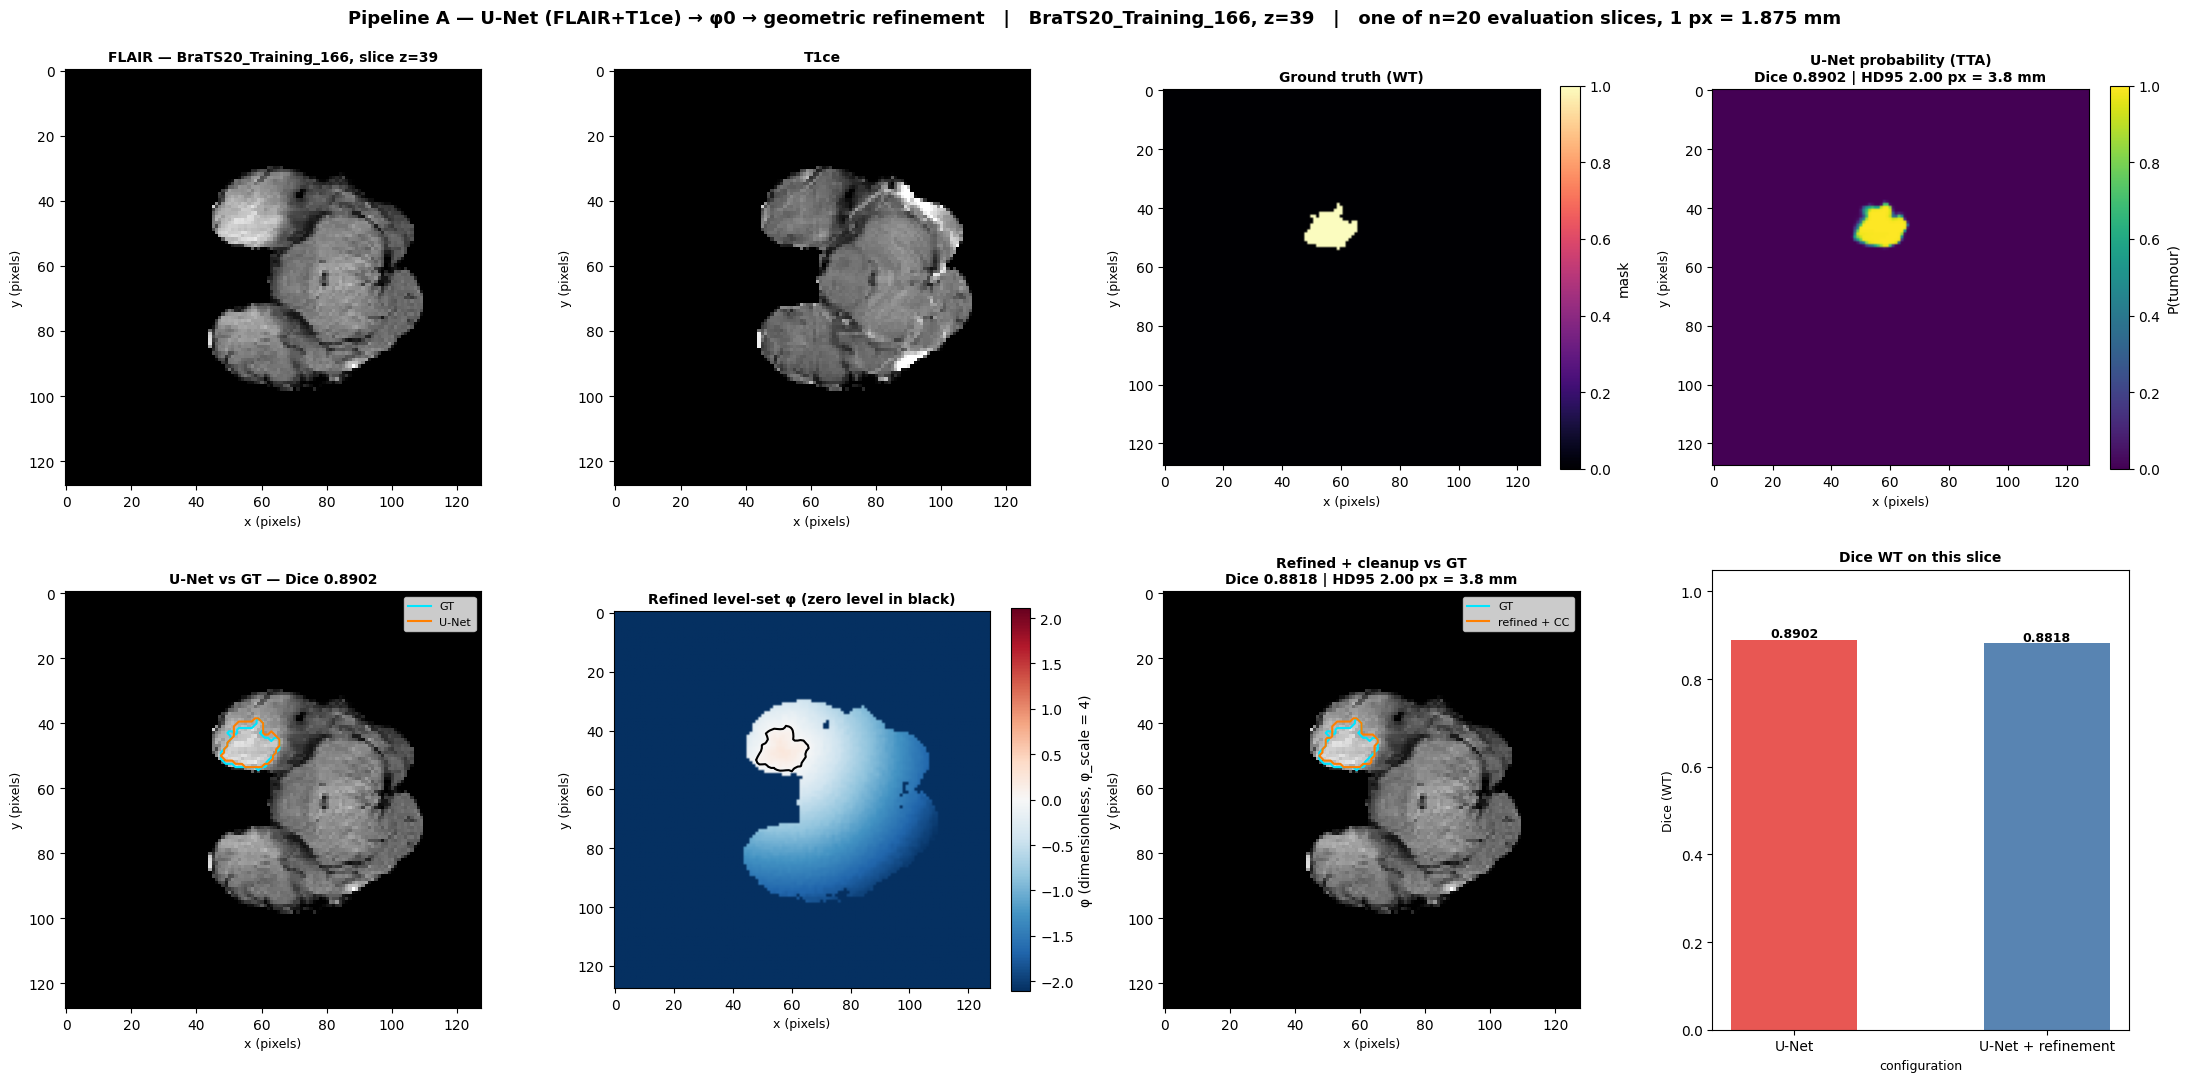

LaTeX caption: Pipeline A on BraTS20_Training_166, axial slice z=39 (median-Dice slice among the n=20 evaluation slices, seed 0). HD95 in pixels of the 128x128 grid (1 px = 1.875 mm).


In [14]:
# ═══════════════════════════════════════════════════════════
# §I  [P2.6] Self-sufficient Figure 5.3: labelled axes + units, colorbars, Dice/HD95 (px and mm), slice ID, n
# ═══════════════════════════════════════════════════════════
def _f32(a): return np.asarray(a, dtype=np.float32)

def visualize(flair, t1ce, gt, prob, unet_mask, phi, refined_mask, d_unet, d_ref, hd_unet_px, hd_ref_px,
              patient, z, n_slices, save):
    mm = config["mm_per_px"]
    flair, t1ce, gt, prob, phi = map(_f32, (flair, t1ce, gt, prob, phi))
    um, rm = _f32(unet_mask), _f32(refined_mask)
    fig, ax = plt.subplots(2, 4, figsize=(22, 11))
    for a in ax.ravel()[:7]:
        a.set_xlabel("x (pixels)", fontsize=9); a.set_ylabel("y (pixels)", fontsize=9)
    ax[0, 0].imshow(flair, cmap="gray"); ax[0, 0].set_title(f"FLAIR — {patient}, slice z={z}", fontweight="bold", fontsize=10)
    ax[0, 1].imshow(t1ce, cmap="gray");  ax[0, 1].set_title("T1ce", fontweight="bold", fontsize=10)
    im = ax[0, 2].imshow(gt, cmap="magma", vmin=0, vmax=1); ax[0, 2].set_title("Ground truth (WT)", fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax[0, 2], fraction=0.046, label="mask")
    im = ax[0, 3].imshow(prob, cmap="viridis", vmin=0, vmax=1)
    ax[0, 3].set_title(f"U-Net probability (TTA)\nDice {d_unet:.4f} | HD95 {hd_unet_px:.2f} px = {hd_unet_px*mm:.1f} mm", fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax[0, 3], fraction=0.046, label="P(tumour)")
    ax[1, 0].imshow(flair, cmap="gray")
    ax[1, 0].contour(gt, levels=[0.5], colors=["#00E5FF"], linewidths=1.5); ax[1, 0].contour(um, levels=[0.5], colors=["#FF7F00"], linewidths=1.5)
    ax[1, 0].plot([], [], color="#00E5FF", label="GT"); ax[1, 0].plot([], [], color="#FF7F00", label="U-Net"); ax[1, 0].legend(loc="upper right", fontsize=8)
    ax[1, 0].set_title(f"U-Net vs GT — Dice {d_unet:.4f}", fontweight="bold", fontsize=10)
    v = float(np.abs(phi).max())
    im = ax[1, 1].imshow(phi, cmap="RdBu_r", vmin=-v, vmax=v); ax[1, 1].contour(phi, levels=[0.0], colors=["k"], linewidths=1.5)
    ax[1, 1].set_title("Refined level-set φ (zero level in black)", fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax[1, 1], fraction=0.046, label="φ (dimensionless, φ_scale = %g)" % config["phi_scale"])
    ax[1, 2].imshow(flair, cmap="gray")
    ax[1, 2].contour(gt, levels=[0.5], colors=["#00E5FF"], linewidths=1.5); ax[1, 2].contour(rm, levels=[0.5], colors=["#FF7F00"], linewidths=1.5)
    ax[1, 2].plot([], [], color="#00E5FF", label="GT"); ax[1, 2].plot([], [], color="#FF7F00", label="refined + CC"); ax[1, 2].legend(loc="upper right", fontsize=8)
    ax[1, 2].set_title(f"Refined + cleanup vs GT\nDice {d_ref:.4f} | HD95 {hd_ref_px:.2f} px = {hd_ref_px*mm:.1f} mm", fontweight="bold", fontsize=10)
    bars = ax[1, 3].bar(["U-Net", "U-Net + refinement"], [d_unet, d_ref], color=["#E53935", "#3b6ea5"], alpha=0.85, width=0.5)
    for b, d in zip(bars, [d_unet, d_ref]):
        ax[1, 3].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f"{d:.4f}", ha="center", fontweight="bold", fontsize=9)
    ax[1, 3].set_ylim(0, 1.05); ax[1, 3].set_ylabel("Dice (WT)", fontsize=9); ax[1, 3].set_xlabel("configuration", fontsize=9)
    ax[1, 3].set_title("Dice WT on this slice", fontweight="bold", fontsize=10)
    fig.suptitle(f"Pipeline A — U-Net (FLAIR+T1ce) → φ0 → geometric refinement   |   {patient}, z={z}   |   "
                 f"one of n={n_slices} evaluation slices, 1 px = {mm:.3f} mm", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.savefig(save, dpi=200, bbox_inches="tight"); print(f"[fig] {save}"); plt.show(); plt.close(fig)

# slice shown = the one with the median refined Dice for the selected config (typical case, not the best one)
r0 = J[(J.cfg_id == best.cfg_id) & (J.seed == 0)].iloc[0]
drs = np.array(json.loads(r0.per_slice_dr)); j = int(np.argsort(drs)[len(drs) // 2]); k = sel[j]
flair, t1ce, gt, prob, brain = SLICES[k]
cfg_best = {**config, **dict(grid)[best.tag]}
phi = refine(flair, t1ce, prob, brain, cfg_best, seed=0 * 1000 + j)
um = prob > 0.5; rm = clean_mask((phi > 0) & brain)
visualize(flair, t1ce, gt, prob, um, phi, rm, dice_bin(um, gt), dice_bin(rm, gt), hd95(um, gt), hd95(rm, gt),
          val_ds.meta[k][0], val_ds.meta[k][1], K, "/kaggle/working/results/fig_5_3_pipelineA.png")
print(f"LaTeX caption: Pipeline A on {val_ds.meta[k][0]}, axial slice z={val_ds.meta[k][1]} (median-Dice slice among the n={K} "
      f"evaluation slices, seed 0). HD95 in pixels of the 128x128 grid (1 px = {config['mm_per_px']:.3f} mm).")


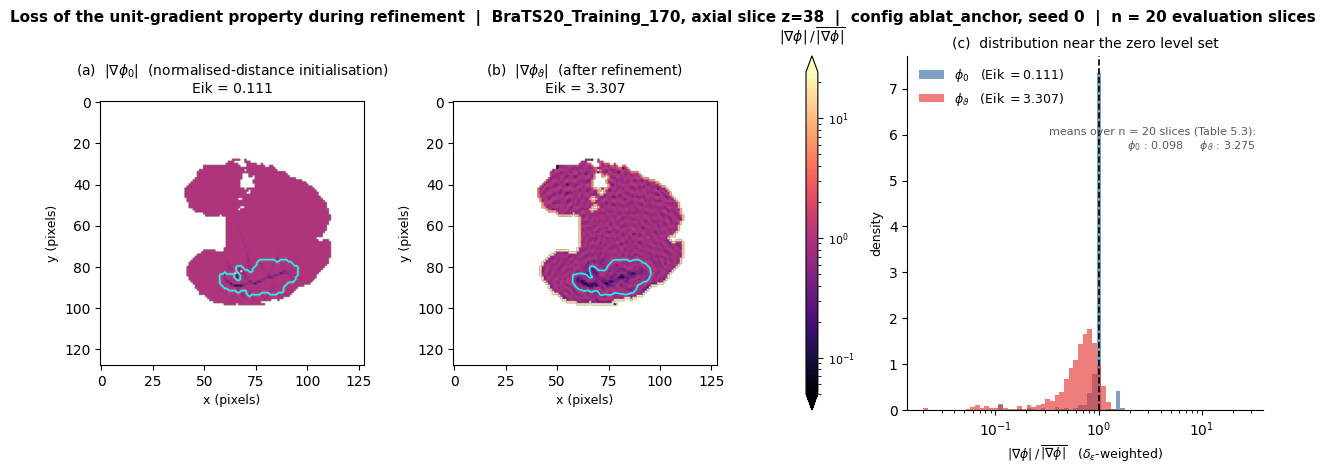

[fig] /kaggle/working/results/fig_5_1_eikonal.pdf   slice: BraTS20_Training_170 z=38   Eik 0.1108 -> 3.3068   means 0.0982 -> 3.2748
LaTeX caption: Loss of the unit-gradient property on BraTS20_Training_170, axial slice z=38 (the slice whose post-refinement deviation is closest to the mean over the n=20 evaluation slices). (a) |grad phi_0| (normalised distance, not an exact SDF); (b) |grad phi_theta| after refinement; (c) delta_eps-weighted distribution of |grad phi| / mean|grad phi|, whose coefficient of variation is Eik. Eik rises from 0.111 to 3.307 on this slice and from 0.098 to 3.275 on average (Table 5.3).


{'k': 765,
 'phi0': array([[-4.       , -3.9778657, -3.955996 , ..., -3.314367 , -3.330773 ,
         -3.3475575],
        [-3.9678168, -3.9455023, -3.923452 , ..., -3.278734 , -3.2953174,
         -3.3122816],
        [-3.9357605, -3.913263 , -3.89103  , ..., -3.2431827, -3.2599473,
         -3.2770944],
        ...,
        [-2.6958416, -2.6628895, -2.6301076, ..., -1.9427507, -1.9721673,
         -1.9980798],
        [-2.7171173, -2.684426 , -2.6519105, ..., -1.9690504, -1.9980798,
         -2.0274508],
        [-2.7387881, -2.7063584, -2.67411  , ..., -1.995773 , -2.024419 ,
         -2.0534134]], dtype=float32),
 'phi': array([[-2.0049958, -2.0049958, -2.0049958, ..., -2.0049958, -2.0049958,
         -2.0049958],
        [-2.0049958, -2.0049958, -2.0049958, ..., -2.0049958, -2.0049958,
         -2.0049958],
        [-2.0049958, -2.0049958, -2.0049958, ..., -2.0049958, -2.0049958,
         -2.0049958],
        ...,
        [-2.0049958, -2.0049958, -2.0049958, ..., -2.0049958, -2.00

In [16]:
# ═══════════════════════════════════════════════════════════
# §G  Figure 5.1 -- eikonal deviation, for the selected configuration (seed 0).
#      Reads back the fields saved by §D (save_fields=True) and recomputes e0/e1 with the SAME
#      eikonal_deviation() used for Table 5.3, so figure and table agree by construction.
#      Self-sufficient (P2.6): labelled axes, colorbar, patient/slice ID, n. Titles comply with B5.
# ═══════════════════════════════════════════════════════════
from matplotlib.colors import LogNorm

z = np.load(f"{config['fields_dir']}/ac9d84e0_s0.npz")
fields = [{"k": k, "phi0": z[f"{k}_phi0"], "phi": z[f"{k}_phi"], "brain": z[f"{k}_brain"]} for k in sel]
eps = config["delta_eps"]
e0 = np.array([eikonal_deviation(f["phi0"], eps) for f in fields])
e1 = np.array([eikonal_deviation(f["phi"], eps) for f in fields])


def _grad_and_weights(phi, eps, h=1.0):
    """|grad phi| and the delta_eps weights, formed exactly as inside eikonal_deviation()."""
    gy, gx = np.gradient(phi.astype(np.float64), h)
    return np.sqrt(gx ** 2 + gy ** 2), _delta_eps(phi.astype(np.float64), eps)


def _weighted_mean(g, w):
    return float(np.sum(w * g) / (np.sum(w) + 1e-12))


def eikonal_figure(fields, e0, e1, eps, item=None, save="/kaggle/working/results/fig_5_1_eikonal.pdf", dpi=300):
    """item: entry of `fields`; if None, the slice whose post-refinement deviation is closest to
    the mean of e1 is used (a typical case -- the figure documents a defect, not a success)."""
    if item is None:
        j = int(np.argmin(np.abs(e1 - e1.mean()))); item = fields[j]
    else:
        j = fields.index(item)
    phi0, phi, brain = item["phi0"], item["phi"], item["brain"]
    patient, zz = val_ds.meta[item["k"]]

    g0, w0 = _grad_and_weights(phi0, eps)
    g1, w1 = _grad_and_weights(phi, eps)
    # Normalise by the delta_eps-weighted mean: phi0 is a RESCALED distance (max-normalised x phi_scale),
    # so |grad phi0| is constant but not 1. The ratio below is the quantity whose weighted
    # coefficient of variation IS the tabulated eikonal deviation.
    g0n, g1n = g0 / (_weighted_mean(g0, w0) + 1e-12), g1 / (_weighted_mean(g1, w1) + 1e-12)
    # refine() sets phi outside the brain to a constant -> artificial gradient ring at the skull,
    # invisible in the metric (delta_eps ~ 0 there) but dominant on a map: masked out.
    m0, m1 = np.where(brain, g0n, np.nan), np.where(brain, g1n, np.nan)
    vmin, vmax = 0.05, max(3.0, np.nanpercentile(m1, 99.5))

    fig = plt.figure(figsize=(15, 4.6))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.045, 1.35], wspace=0.4)
    ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 3])]
    cax = fig.add_subplot(gs[0, 2])
    for a, m, t, ph, e in [
        (ax[0], m0, r"(a)  $|\nabla\phi_0|$  (normalised-distance initialisation)", phi0, e0[j]),
        (ax[1], m1, r"(b)  $|\nabla\phi_\vartheta|$  (after refinement)", phi, e1[j]),
    ]:
        im = a.imshow(m, cmap="magma", norm=LogNorm(vmin=vmin, vmax=vmax))
        a.contour(ph, levels=[0.0], colors="cyan", linewidths=1.2)
        a.set_title(t + "\nEik = %.3f" % e, fontsize=10)
        a.set_xlabel("x (pixels)", fontsize=9); a.set_ylabel("y (pixels)", fontsize=9)
    cb = fig.colorbar(im, cax=cax, extend="both"); cb.ax.tick_params(labelsize=8)
    cax.set_title(r"$|\nabla\phi|\,/\,\overline{|\nabla\phi|}$", fontsize=10, pad=10)

    # delta_eps-weighted histogram: panel (c) is the distribution whose coefficient of variation the table reports.
    sel_px = brain & (w1 > 1e-4)
    hi = max(6.0, np.nanpercentile(g1n[sel_px], 99.9))
    bins = np.logspace(np.log10(0.02), np.log10(hi), 70)
    ax[2].hist(g0n[brain].ravel(), bins=bins, weights=w0[brain].ravel(), density=True, alpha=0.65,
               color="#3b6ea5", label=r"$\phi_0$   (Eik $=%.3f$)" % e0[j])
    ax[2].hist(g1n[brain].ravel(), bins=bins, weights=w1[brain].ravel(), density=True, alpha=0.65,
               color="#E53935", label=r"$\phi_\vartheta$   (Eik $=%.3f$)" % e1[j])
    ax[2].axvline(1.0, color="k", ls="--", lw=1.2); ax[2].set_xscale("log")
    ax[2].set_xlabel(r"$|\nabla\phi|\,/\,\overline{|\nabla\phi|}$   ($\delta_\varepsilon$-weighted)", fontsize=9)
    ax[2].set_ylabel("density", fontsize=9)
    ax[2].set_title("(c)  distribution near the zero level set", fontsize=10)
    ax[2].legend(fontsize=9, frameon=False, loc="upper left")
    ax[2].spines[["top", "right"]].set_visible(False)
    ax[2].text(0.98, 0.80, "means over n = %d slices (Table 5.3):\n" r"$\phi_0$ : %.3f     $\phi_\vartheta$ : %.3f"
               % (len(e1), np.nanmean(e0), np.nanmean(e1)), transform=ax[2].transAxes, ha="right", va="top",
               fontsize=8, color="0.35")
    fig.suptitle(f"Loss of the unit-gradient property during refinement  |  {patient}, axial slice z={zz}  |  "
                 f"config {best.tag}, seed 0  |  n = {len(e1)} evaluation slices", fontsize=11, fontweight="bold")
    fig.savefig(save, dpi=dpi, bbox_inches="tight"); plt.show(); plt.close(fig)
    print(f"[fig] {save}   slice: {patient} z={zz}   Eik {e0[j]:.4f} -> {e1[j]:.4f}   "
          f"means {np.nanmean(e0):.4f} -> {np.nanmean(e1):.4f}")
    print(f"LaTeX caption: Loss of the unit-gradient property on {patient}, axial slice z={zz} (the slice whose "
          f"post-refinement deviation is closest to the mean over the n={len(e1)} evaluation slices). "
          f"(a) |grad phi_0| (normalised distance, not an exact SDF); (b) |grad phi_theta| after refinement; "
          f"(c) delta_eps-weighted distribution of |grad phi| / mean|grad phi|, whose coefficient of variation is Eik. "
          f"Eik rises from {e0[j]:.3f} to {e1[j]:.3f} on this slice and from {np.nanmean(e0):.3f} to {np.nanmean(e1):.3f} on average (Table 5.3).")
    return item


eikonal_figure(fields, e0, e1, eps)
